In [1]:
# 💰 OCR Cost Calculator
# Compare costs at different scales: 1K to 10M pages/month

from ocr_gauntlet.visualize import cost_table
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Placeholder avg CERs (replace with real numbers after running the gauntlet)
avg_cers = {
    "Tesseract": 0.15,
    "Docling + tesseract": 0.12,
    "dots.ocr (1.7B)": 0.08,
    "Mistral OCR v3": 0.05,
    "Gemini 3 Flash": 0.03,
}

for vol in [1_000, 10_000, 100_000, 1_000_000, 10_000_000]:
    print(f"\n{'=' * 60}\n  📊 {vol:,} pages/month\n{'=' * 60}")
    display(cost_table(vol, avg_cers))


  📊 1,000 pages/month


,Engine,Avg CER,Monthly Cost,Pricing
0,Tesseract,0.150,Free,CPU only
1,Docling + tesseract,0.120,Free,CPU only
2,dots.ocr (1.7B),0.080,Free,~$0.50/hr GPU
3,Mistral OCR v3,0.050,$2,$2/1K pages
4,Gemini 3 Flash,0.030,$1,~$0.50/M input tokens



  📊 10,000 pages/month


,Engine,Avg CER,Monthly Cost,Pricing
0,Tesseract,0.150,Free,CPU only
1,Docling + tesseract,0.120,Free,CPU only
2,dots.ocr (1.7B),0.080,Free,~$0.50/hr GPU
3,Mistral OCR v3,0.050,$20,$2/1K pages
4,Gemini 3 Flash,0.030,$8,~$0.50/M input tokens



  📊 100,000 pages/month


,Engine,Avg CER,Monthly Cost,Pricing
0,Tesseract,0.150,Free,CPU only
1,Docling + tesseract,0.120,Free,CPU only
2,dots.ocr (1.7B),0.080,Free,~$0.50/hr GPU
3,Mistral OCR v3,0.050,$200,$2/1K pages
4,Gemini 3 Flash,0.030,$80,~$0.50/M input tokens



  📊 1,000,000 pages/month


,Engine,Avg CER,Monthly Cost,Pricing
0,Tesseract,0.150,Free,CPU only
1,Docling + tesseract,0.120,Free,CPU only
2,dots.ocr (1.7B),0.080,Free,~$0.50/hr GPU
3,Mistral OCR v3,0.050,"$2,000",$2/1K pages
4,Gemini 3 Flash,0.030,$800,~$0.50/M input tokens



  📊 10,000,000 pages/month


,Engine,Avg CER,Monthly Cost,Pricing
0,Tesseract,0.150,Free,CPU only
1,Docling + tesseract,0.120,Free,CPU only
2,dots.ocr (1.7B),0.080,Free,~$0.50/hr GPU
3,Mistral OCR v3,0.050,"$20,000",$2/1K pages
4,Gemini 3 Flash,0.030,"$8,000",~$0.50/M input tokens


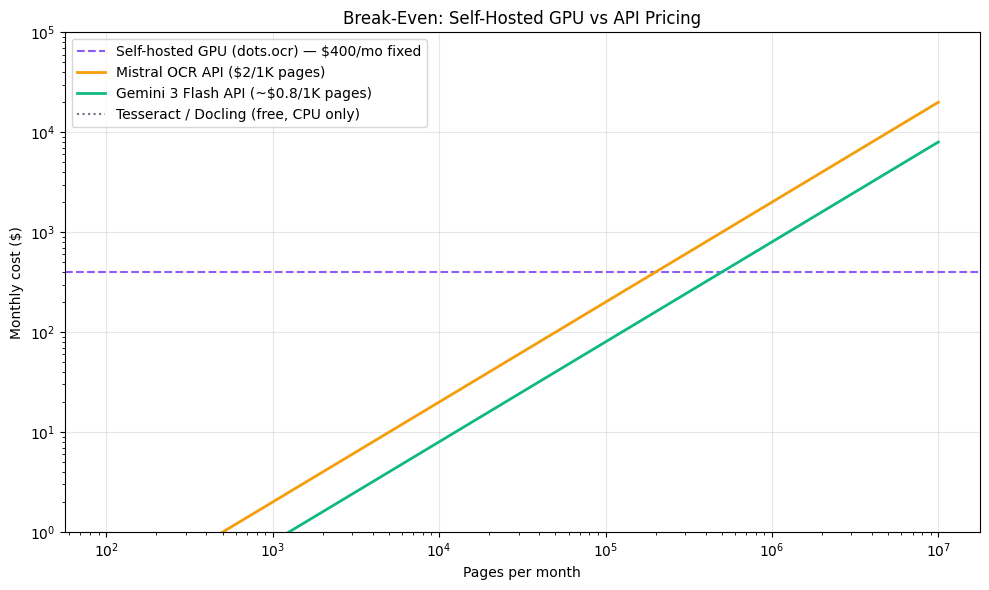


Break-even vs Mistral API: 200,000 pages/month
Break-even vs Gemini API:  500,000 pages/month


In [3]:
# Break-even chart: self-hosting GPU vs API pricing

volumes = np.logspace(2, 7, 100)  # 100 to 10M pages/month

# Monthly costs
gpu_fixed = 400  # ~$0.50/hr * 24 * 30 for a dedicated GPU (dots.ocr)
mistral_per_page = 2.0 / 1000
gemini_per_page = 0.8 / 1000

fig, ax = plt.subplots(figsize=(10, 6))
ax.axhline(
    y=gpu_fixed,
    color="#8B5CF6",
    linestyle="--",
    label=f"Self-hosted GPU (dots.ocr) — ${gpu_fixed}/mo fixed",
)
ax.plot(
    volumes,
    volumes * mistral_per_page,
    color="#F59E0B",
    linewidth=2,
    label="Mistral OCR API ($2/1K pages)",
)
ax.plot(
    volumes,
    volumes * gemini_per_page,
    color="#10B981",
    linewidth=2,
    label="Gemini 3 Flash API (~$0.8/1K pages)",
)
ax.axhline(
    y=0, color="#6B7280", linestyle=":", label="Tesseract / Docling (free, CPU only)"
)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Pages per month")
ax.set_ylabel("Monthly cost ($)")
ax.set_title("Break-Even: Self-Hosted GPU vs API Pricing")
ax.legend()
ax.set_ylim(1, 100_000)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Break-even points
print(f"\nBreak-even vs Mistral API: {gpu_fixed / mistral_per_page:,.0f} pages/month")
print(f"Break-even vs Gemini API:  {gpu_fixed / gemini_per_page:,.0f} pages/month")